# Group-Aware Evaluation Using the Dataset API

This notebook demonstrates a compact leakage-aware machine-learning workflow using the package-level `generate_grouped_monoexponential_dataset()` function.

The main objective is to compare:

1. an ordinary row-wise random train-test split;
2. a group-aware split that keeps all Poisson realizations of one physical parameter set together.

Unlike the longer data-leakage notebook, this workflow focuses on the reusable Python API and only the main experimental conclusions.

## 1. Imports and reproducibility

The grouped generator returns a `SyntheticDataset` containing:

- measured TCSPC histograms in `dataset.X`;
- the shared time axis in `dataset.time`;
- physical parameters and group identifiers in `dataset.metadata`.

The lifetime target is selected explicitly from the metadata.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from tcspc_toolkit.datasets import (
    generate_grouped_monoexponential_dataset,
)

## 2. Generate a grouped synthetic dataset

Each parameter group contains one underlying mono-exponential decay and several independent Poisson realizations.

Curves inside the same group therefore share:

- lifetime;
- amplitude;
- background;
- target expected photon count;
- expected decay curve.

Only their measured Poisson counts differ.

In [2]:
n_time_bins = 256

time = np.linspace(
    start=0.0,
    stop=12.0,
    num=n_time_bins,
    dtype=np.float64,
)

n_parameter_groups = 500
n_realizations_per_group = 5

lifetime_range = (0.5, 5.0)
amplitude_range = (500.0, 10_000.0)
background_range = (0.0, 10.0)
photon_count_range = (1_000, 100_000)

random_seed = 42

In [3]:
dataset = generate_grouped_monoexponential_dataset(
    n_parameter_groups=n_parameter_groups,
    n_realizations_per_group=n_realizations_per_group,
    time=time,
    lifetime_range=lifetime_range,
    amplitude_range=amplitude_range,
    background_range=background_range,
    photon_count_range=photon_count_range,
    random_seed=random_seed,
)

In [4]:
print(f"X shape: {dataset.X.shape}")
print(f"Time shape: {dataset.time.shape}")
print(f"Metadata shape: {dataset.metadata.shape}")

dataset.metadata.head()

X shape: (2500, 256)
Time shape: (256,)
Metadata shape: (2500, 9)


,curve_id,parameter_group,realization_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,0,0,3.982802,963.025113,0.079705,78026,78026.0,78017
1,1,0,1,3.982802,963.025113,0.079705,78026,78026.0,77987
2,2,0,2,3.982802,963.025113,0.079705,78026,78026.0,77740
3,3,0,3,3.982802,963.025113,0.079705,78026,78026.0,78602
4,4,0,4,3.982802,963.025113,0.079705,78026,78026.0,78034


In [5]:
dataset.metadata.columns.tolist()

['curve_id',
 'parameter_group',
 'realization_id',
 'lifetime_true',
 'amplitude_true',
 'background_true',
 'photon_count_target',
 'photon_count_expected',
 'photon_count']

## 3. Verify the grouped dataset structure

Before using the data for machine learning, we verify that:

- the total number of curves is correct;
- every group contains the requested number of realizations;
- physical parameters remain constant within each group.

In [6]:
expected_n_curves = (
    n_parameter_groups
    * n_realizations_per_group
)

assert dataset.X.shape == (
    expected_n_curves,
    n_time_bins,
)

assert dataset.time.shape == (
    n_time_bins,
)

assert len(dataset.metadata) == expected_n_curves

assert (
    dataset.metadata["parameter_group"].nunique()
    == n_parameter_groups
)

print("General dataset dimensions verified.")

General dataset dimensions verified.


In [7]:
group_sizes = dataset.metadata.groupby(
    "parameter_group"
).size()

group_sizes.head()

parameter_group
0    5
1    5
2    5
3    5
4    5
dtype: int64

In [8]:
assert (
    group_sizes == n_realizations_per_group
).all()

print(
    "Every parameter group contains",
    n_realizations_per_group,
    "realizations.",
)

Every parameter group contains 5 realizations.


In [9]:
parameter_columns = [
    "lifetime_true",
    "amplitude_true",
    "background_true",
    "photon_count_target",
    "photon_count_expected",
]

within_group_unique_counts = (
    dataset.metadata
    .groupby("parameter_group")[
        parameter_columns
    ]
    .nunique()
)

within_group_unique_counts.head()

,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected
parameter_group,,,,,
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,1,1
3,1,1,1,1,1
4,1,1,1,1,1


In [10]:
assert (
    within_group_unique_counts == 1
).all().all()

print(
    "Physical parameters are constant "
    "within every parameter group."
)

Physical parameters are constant within every parameter group.


## 4. Inspect repeated Poisson realizations

The curves below have the same underlying physical parameters but independent photon-counting noise.

In [11]:
selected_group = 0

selected_rows = dataset.metadata[
    dataset.metadata["parameter_group"]
    == selected_group
]

selected_indices = selected_rows.index.to_numpy()

selected_rows

,curve_id,parameter_group,realization_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,0,0,3.982802,963.025113,0.079705,78026,78026.0,78017
1,1,0,1,3.982802,963.025113,0.079705,78026,78026.0,77987
2,2,0,2,3.982802,963.025113,0.079705,78026,78026.0,77740
3,3,0,3,3.982802,963.025113,0.079705,78026,78026.0,78602
4,4,0,4,3.982802,963.025113,0.079705,78026,78026.0,78034


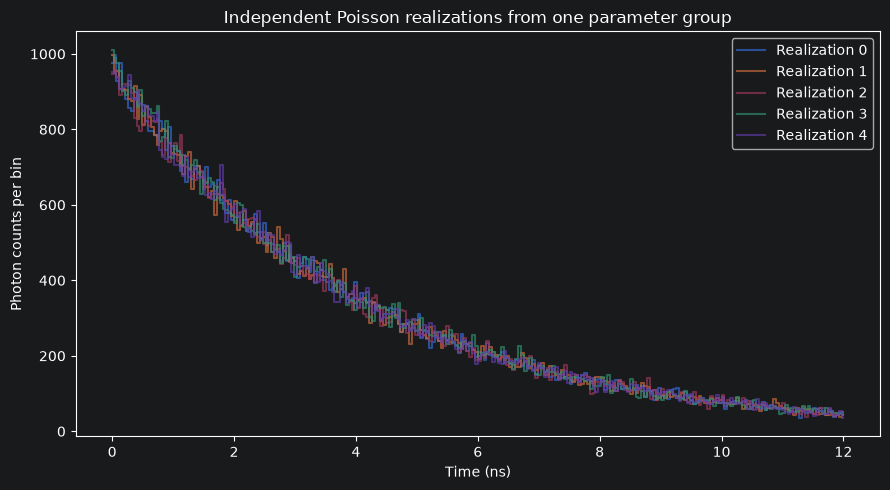

In [12]:
plt.figure(figsize=(9, 5))

for index in selected_indices:
    realization_id = int(
        dataset.metadata.loc[
            index,
            "realization_id",
        ]
    )

    plt.step(
        dataset.time,
        dataset.X[index],
        where="mid",
        alpha=0.65,
        label=f"Realization {realization_id}",
    )

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title(
    "Independent Poisson realizations "
    "from one parameter group"
)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Prepare normalized inputs and the lifetime target

The measured histograms are normalized by their total measured photon count.

This reduces the influence of absolute intensity and makes the models primarily use the decay shape.

The prediction target is selected explicitly from the `lifetime_true` metadata column.

In [13]:
X = dataset.X.astype(np.float64)

photon_sums = X.sum(
    axis=1,
    keepdims=True,
)

if np.any(photon_sums == 0):
    raise ValueError(
        "At least one curve contains zero total counts."
    )

X_normalized = X / photon_sums

In [14]:
y = dataset.get_targets(
    "lifetime_true"
).ravel()

groups = dataset.metadata[
    "parameter_group"
].to_numpy(dtype=np.int64)

In [15]:
row_sums = X_normalized.sum(axis=1)

print(
    f"X_normalized shape: {X_normalized.shape}"
)
print(f"y shape: {y.shape}")
print(f"groups shape: {groups.shape}")

print(
    "Minimum normalized row sum:",
    row_sums.min(),
)
print(
    "Maximum normalized row sum:",
    row_sums.max(),
)

assert np.allclose(
    row_sums,
    1.0,
)

X_normalized shape: (2500, 256)
y shape: (2500,)
groups shape: (2500,)
Minimum normalized row sum: 0.9999999999999996
Maximum normalized row sum: 1.0000000000000002


## 6. Ordinary row-wise random split

An ordinary random split treats all curves as independent observations.

As a result, one Poisson realization from a parameter group may enter the training set while another realization of the same underlying expected curve enters the test set.

In [16]:
all_indices = np.arange(
    len(y),
    dtype=np.int64,
)

(
    train_indices_random,
    test_indices_random,
) = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
)

In [17]:
random_train_groups = set(
    groups[train_indices_random]
)

random_test_groups = set(
    groups[test_indices_random]
)

random_group_overlap = (
    random_train_groups
    & random_test_groups
)

print(
    "Training curves:",
    train_indices_random.size,
)

print(
    "Test curves:",
    test_indices_random.size,
)

print(
    "Groups shared by training and test:",
    len(random_group_overlap),
)

Training curves: 2000
Test curves: 500
Groups shared by training and test: 329


## 7. Group-aware split

`GroupShuffleSplit` assigns complete parameter groups to either training or testing.

Therefore, no realization of a test-group decay is present in the training data.

In [18]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

(
    train_indices_grouped,
    test_indices_grouped,
) = next(
    group_splitter.split(
        X_normalized,
        y,
        groups=groups,
    )
)

In [19]:
grouped_train_groups = set(
    groups[train_indices_grouped]
)

grouped_test_groups = set(
    groups[test_indices_grouped]
)

grouped_group_overlap = (
    grouped_train_groups
    & grouped_test_groups
)

print(
    "Training curves:",
    train_indices_grouped.size,
)

print(
    "Test curves:",
    test_indices_grouped.size,
)

print(
    "Groups shared by training and test:",
    len(grouped_group_overlap),
)

assert len(grouped_group_overlap) == 0

Training curves: 2000
Test curves: 500
Groups shared by training and test: 0


In [20]:
overlap_summary = pd.DataFrame(
    {
        "split_protocol": [
            "Row-wise random",
            "Group-aware",
        ],
        "shared_parameter_groups": [
            len(random_group_overlap),
            len(grouped_group_overlap),
        ],
        "training_curves": [
            train_indices_random.size,
            train_indices_grouped.size,
        ],
        "test_curves": [
            test_indices_random.size,
            test_indices_grouped.size,
        ],
    }
)

overlap_summary

,split_protocol,shared_parameter_groups,training_curves,test_curves
0,Row-wise random,329,2000,500
1,Group-aware,0,2000,500


## 8. Define the baseline models

Two models are used:

- a mean-prediction baseline;
- a Random Forest regressor.

The models are recreated separately for each split protocol so that no fitted state is shared between experiments.

In [21]:
def build_models() -> dict[str, object]:
    return {
        "Mean baseline": DummyRegressor(
            strategy="mean",
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
        ),
    }

## 9. Define the evaluation metrics

The evaluation includes:

- mean absolute error;
- median absolute error;
- mean relative error;
- coefficient of determination, \(R^2\).

In [22]:
def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    absolute_errors = np.abs(
        y_pred - y_true
    )

    relative_errors = (
        absolute_errors / y_true
    )

    return {
        "MAE (ns)": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "Median AE (ns)": median_absolute_error(
            y_true,
            y_pred,
        ),
        "Mean relative error": float(
            np.mean(relative_errors)
        ),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }

## 10. Define a reusable training workflow

The function below trains all baseline models for one split protocol and returns:

- a metrics table;
- model predictions for later visualization.

In [23]:
def run_protocol(
    protocol_name: str,
    train_indices: np.ndarray,
    test_indices: np.ndarray,
) -> tuple[
    pd.DataFrame,
    dict[str, np.ndarray],
]:
    X_train = X_normalized[
        train_indices
    ]
    X_test = X_normalized[
        test_indices
    ]

    y_train = y[
        train_indices
    ]
    y_test = y[
        test_indices
    ]

    result_rows = []
    predictions = {}

    for model_name, model in build_models().items():
        model.fit(
            X_train,
            y_train,
        )

        y_pred = model.predict(
            X_test
        )

        predictions[model_name] = y_pred

        result_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                **evaluate_predictions(
                    y_test,
                    y_pred,
                ),
            }
        )

    return (
        pd.DataFrame(result_rows),
        predictions,
    )

## 11. Train and evaluate both protocols

In [24]:
random_metrics, random_predictions = (
    run_protocol(
        protocol_name="Row-wise random",
        train_indices=train_indices_random,
        test_indices=test_indices_random,
    )
)

random_metrics

,protocol,model,MAE (ns),Median AE (ns),Mean relative error,R2
0,Row-wise random,Mean baseline,1.151632,1.244408,0.707403,-0.001298
1,Row-wise random,Random Forest,0.044228,0.023641,0.015646,0.997161


In [25]:
grouped_metrics, grouped_predictions = (
    run_protocol(
        protocol_name="Group-aware",
        train_indices=train_indices_grouped,
        test_indices=test_indices_grouped,
    )
)

grouped_metrics

,protocol,model,MAE (ns),Median AE (ns),Mean relative error,R2
0,Group-aware,Mean baseline,1.215243,1.241192,0.785965,-0.000642
1,Group-aware,Random Forest,0.044745,0.025158,0.016249,0.997285


In [26]:
metrics = pd.concat(
    [
        random_metrics,
        grouped_metrics,
    ],
    ignore_index=True,
)

metrics

,protocol,model,MAE (ns),Median AE (ns),Mean relative error,R2
0,Row-wise random,Mean baseline,1.151632,1.244408,0.707403,-0.001298
1,Row-wise random,Random Forest,0.044228,0.023641,0.015646,0.997161
2,Group-aware,Mean baseline,1.215243,1.241192,0.785965,-0.000642
3,Group-aware,Random Forest,0.044745,0.025158,0.016249,0.997285


## 12. Compare the evaluation results

If the row-wise random split produces much better results than the group-aware split, this indicates that related Poisson realizations shared between training and testing make the ordinary evaluation overly optimistic.

In [27]:
mae_comparison = metrics.pivot(
    index="model",
    columns="protocol",
    values="MAE (ns)",
)

mae_comparison

protocol,Group-aware,Row-wise random
model,,
Mean baseline,1.215243,1.151632
Random Forest,0.044745,0.044228


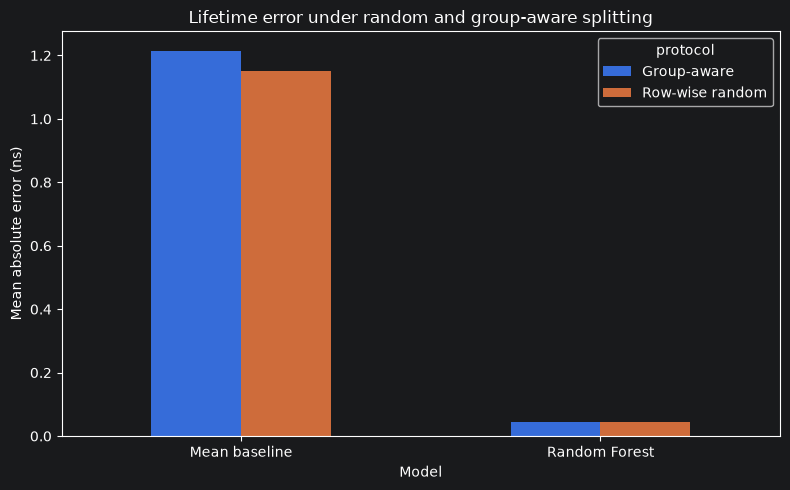

In [28]:
mae_comparison.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.ylabel("Mean absolute error (ns)")
plt.xlabel("Model")
plt.title(
    "Lifetime error under random "
    "and group-aware splitting"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Inspect Random Forest predictions

The scatter plot compares true and predicted lifetimes for the Random Forest under both evaluation protocols.

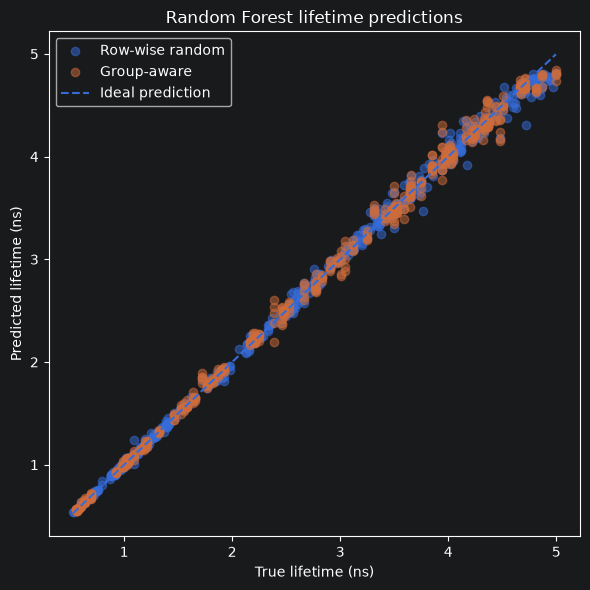

In [29]:
random_test_lifetimes = y[
    test_indices_random
]

grouped_test_lifetimes = y[
    test_indices_grouped
]

plt.figure(figsize=(6, 6))

plt.scatter(
    random_test_lifetimes,
    random_predictions["Random Forest"],
    alpha=0.5,
    label="Row-wise random",
)

plt.scatter(
    grouped_test_lifetimes,
    grouped_predictions["Random Forest"],
    alpha=0.5,
    label="Group-aware",
)

axis_min = min(
    random_test_lifetimes.min(),
    grouped_test_lifetimes.min(),
)

axis_max = max(
    random_test_lifetimes.max(),
    grouped_test_lifetimes.max(),
)

plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    label="Ideal prediction",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Predicted lifetime (ns)")
plt.title(
    "Random Forest lifetime predictions"
)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Conclusions

This compact workflow demonstrates that:

- `generate_grouped_monoexponential_dataset()` creates several independent Poisson realizations for each underlying parameter set;
- the `SyntheticDataset` metadata contains both regression targets and grouping information;
- a row-wise random split can place related realizations in both training and test subsets;
- `GroupShuffleSplit` removes parameter-group overlap;
- group-aware evaluation should be preferred when repeated realizations share the same underlying simulation parameters.

This notebook intentionally omits the extended lifetime-holdout, noise-robustness, and conditional-error analyses from the longer data-leakage study.